<a href="https://www.kaggle.com/code/hrishikeshsoudagar/movie-recommendation?scriptVersionId=301000451" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Reading Dataset

In [2]:
df=pd.read_csv('/kaggle/input/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv')

In [3]:
df

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1379960,851655,Raphael - Maravilloso,0.000,0,Released,2005-05-13,0,0,False,NaN,...,Raphael - Maravilloso,NaN,0.6000,/d28wkRPxjZGCfItrdfpaRH0VJJc.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1379961,851659,Doru,0.000,0,Released,2021-08-26,0,18,False,NaN,...,Doru,"The story of Doru, a story about loneliness an...",0.6000,/slSTnhlOVUMEYGfArnwykZuIAmP.jpg,NaN,Drama,NaN,NaN,Romanian,NaN
1379962,851661,they're coming,0.000,0,Released,2021-07-17,0,67,False,NaN,...,they're coming,Two strangers that met through Craigslist in t...,0.6000,/pYlyRVtrj5u9Yqw4bjX1iHXd1oN.jpg,NaN,Horror,Dream Distribution,NaN,NaN,"ufo, alien abduction, alien contact, ufo sighting"
1379963,851662,Tallenes tale,0.000,0,Released,1949-07-18,0,2,False,NaN,...,Tallenes tale,About the problems in connection with Denmark'...,0.6000,NaN,NaN,Documentary,NaN,Denmark,NaN,NaN


In [4]:
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [5]:
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.379965e+06,1.379965e+06,1.379965e+06,1.379965e+06,1.379965e+06,1.379965e+06,1.379965e+06
mean,8.774729e+05,1.592839e+00,1.554861e+01,6.274207e+05,4.442970e+01,2.398930e+05,1.039643e+00
std,4.663332e+05,2.879279e+00,2.891577e+02,1.926237e+07,6.082175e+01,5.095597e+06,6.899967e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,4.832000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,8.934050e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,1.287168e+06,2.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.370000e-01
max,1.644968e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379965 entries, 0 to 1379964
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1379965 non-null  int64  
 1   title                 1379947 non-null  object 
 2   vote_average          1379965 non-null  float64
 3   vote_count            1379965 non-null  int64  
 4   status                1379965 non-null  object 
 5   release_date          1084096 non-null  object 
 6   revenue               1379965 non-null  int64  
 7   runtime               1379965 non-null  int64  
 8   adult                 1379965 non-null  bool   
 9   backdrop_path         345879 non-null   object 
 10  budget                1379965 non-null  int64  
 11  homepage              142390 non-null   object 
 12  imdb_id               659636 non-null   object 
 13  original_language     1379965 non-null  object 
 14  original_title        1379947 non-

In [7]:
df.isnull().sum()

id                            0
title                        18
vote_average                  0
vote_count                    0
status                        0
release_date             295869
revenue                       0
runtime                       0
adult                         0
backdrop_path           1034086
budget                        0
homepage                1237575
imdb_id                  720329
original_language             0
original_title               18
overview                 313386
popularity                    0
poster_path              482715
tagline                 1187808
genres                   599815
production_companies     787742
production_countries     660753
spoken_languages         634690
keywords                1035145
dtype: int64

Drop Irrelevant Columns

In [8]:
df.drop(columns=["vote_average","vote_count","status","release_date","revenue","adult","backdrop_path","budget","homepage","imdb_id","original_language","original_title","poster_path","tagline","production_companies","production_countries","spoken_languages","keywords"],inplace=True)

In [9]:
df

,id,title,runtime,overview,popularity,genres
0,27205,Inception,148,"Cobb, a skilled thief who commits corporate es...",83.9520,"Action, Science Fiction, Adventure"
1,157336,Interstellar,169,The adventures of a group of explorers who mak...,140.2410,"Adventure, Drama, Science Fiction"
2,155,The Dark Knight,152,Batman raises the stakes in his war on crime. ...,130.6430,"Drama, Action, Crime, Thriller"
3,19995,Avatar,162,"In the 22nd century, a paraplegic Marine is di...",79.9320,"Action, Adventure, Fantasy, Science Fiction"
4,24428,The Avengers,143,When an unexpected enemy emerges and threatens...,98.0820,"Science Fiction, Action, Adventure"
...,...,...,...,...,...,...
1379960,851655,Raphael - Maravilloso,0,NaN,0.6000,NaN
1379961,851659,Doru,18,"The story of Doru, a story about loneliness an...",0.6000,Drama
1379962,851661,they're coming,67,Two strangers that met through Craigslist in t...,0.6000,Horror
1379963,851662,Tallenes tale,2,About the problems in connection with Denmark'...,0.6000,Documentary


Check For Missing Values

In [10]:
df.isnull().sum()

id                 0
title             18
runtime            0
overview      313386
popularity         0
genres        599815
dtype: int64

Handling Missing Values

In [11]:
df['overview'] = df['overview'].fillna('')
df['genres'] = df['genres'].fillna('Unknown')

df.dropna(subset=['title'], inplace=True)

In [12]:
df.isnull().sum()

id            0
title         0
runtime       0
overview      0
popularity    0
genres        0
dtype: int64

Reducing Datasize

In [13]:
df = df.sample(20000,random_state=42)

In [14]:
df

,id,title,runtime,overview,popularity,genres
628679,1501710,Surrender at Port Arthur,4,Short film about the surrender at Port Arthur.,0.0071,War
790807,1469471,Proxies,13,"Jen creates a machine to help with her goals, ...",0.0143,"Science Fiction, Thriller, Drama"
810531,1485410,Brazilian Beach Boys 5,73,Gorgeous young Brazilian men show off their fi...,0.0000,Unknown
1049537,197991,What's in the Bible? Volume 11: Spreading the ...,0,Host Buck Denver and his friends make understa...,0.6000,Unknown
770946,1352731,As She Dreams,87,Morgan (Layla Sin) is having some really hot d...,0.0000,Unknown
...,...,...,...,...,...,...
111842,161844,Betty Boop's Ker-Choo,7,"Betty, Koko, and Bimbo drive at the auto races...",0.6000,"Animation, Comedy"
988546,642519,Sustingusi Laike,0,,0.6000,Unknown
979399,653589,Hang 'Em Low,0,"Gopher Grover, a young jovial southern man wit...",0.6000,Comedy
599141,1558433,Gender Benders,91,"Throughout history, men and women have been fo...",0.0000,Unknown


EDA Visualization

Movie Popularity Distribution

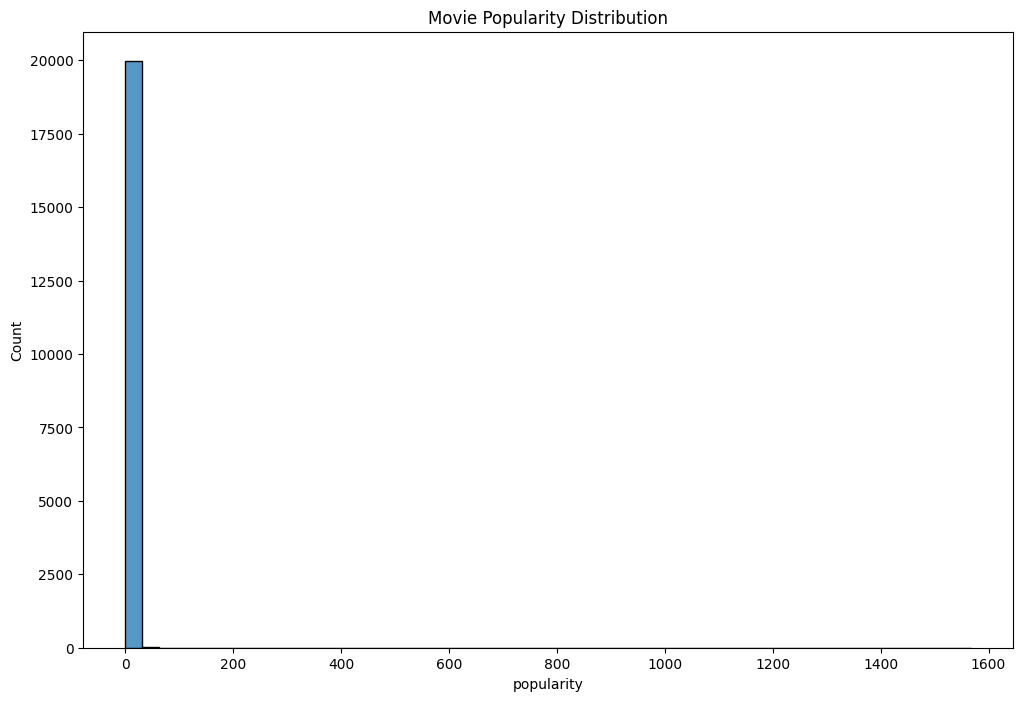

In [15]:
plt.figure(figsize=(12,8))
sns.histplot(df['popularity'], bins=50)
plt.title("Movie Popularity Distribution")
plt.show()

Run Time Distribution

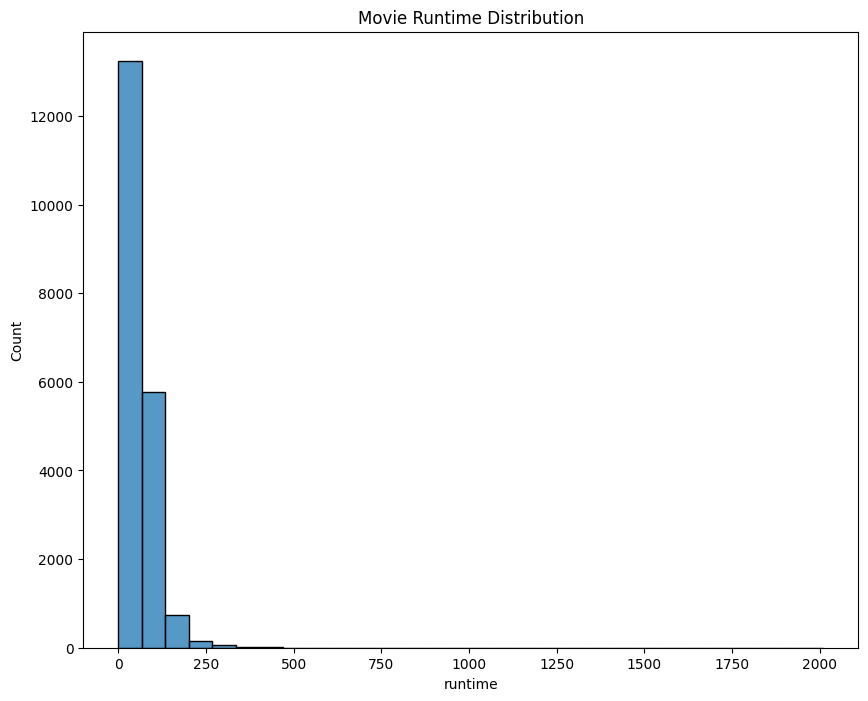

In [16]:
plt.figure(figsize=(10,8))
sns.histplot(df['runtime'], bins=30)
plt.title("Movie Runtime Distribution")
plt.show()

Top 20 Most Popular Movies

In [17]:
top_movies = df.sort_values(by='popularity', ascending=False).head(20)

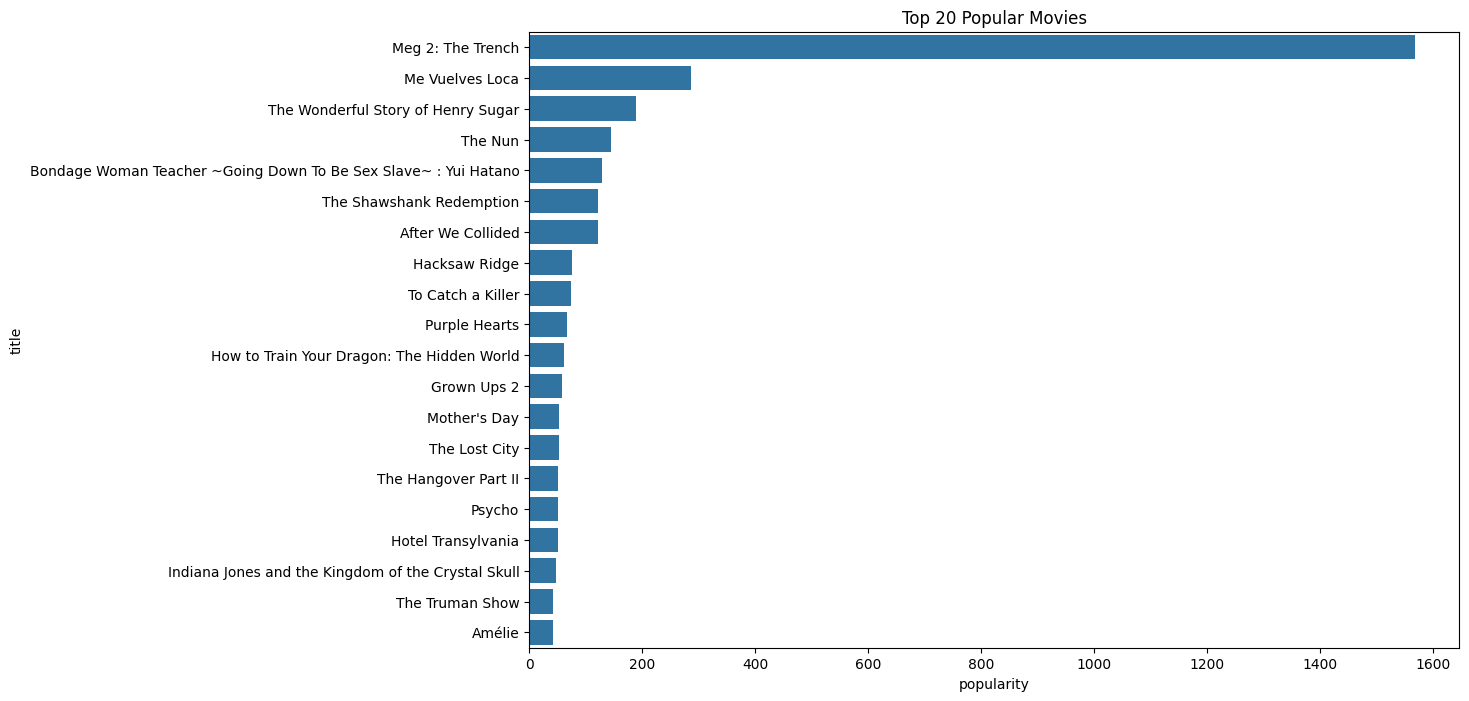

In [18]:
plt.figure(figsize=(12,8))
sns.barplot(x=top_movies['popularity'],y=top_movies['title'])
plt.title("Top 20 Popular Movies")
plt.show()

Genre Count Plot

In [19]:
genre_data = df['genres'].value_counts().head(20)
genre_data

genres
Unknown               8598
Documentary           2281
Drama                 1826
Comedy                 982
Animation              552
Music                  459
Horror                 374
Drama, Romance         185
Romance                149
Comedy, Drama          143
Thriller               127
Action                 110
Drama, Comedy          103
Documentary, Music      90
Comedy, Romance         83
Crime                   79
Drama, Thriller         71
Western                 69
Romance, Drama          61
Music, Documentary      59
Name: count, dtype: int64

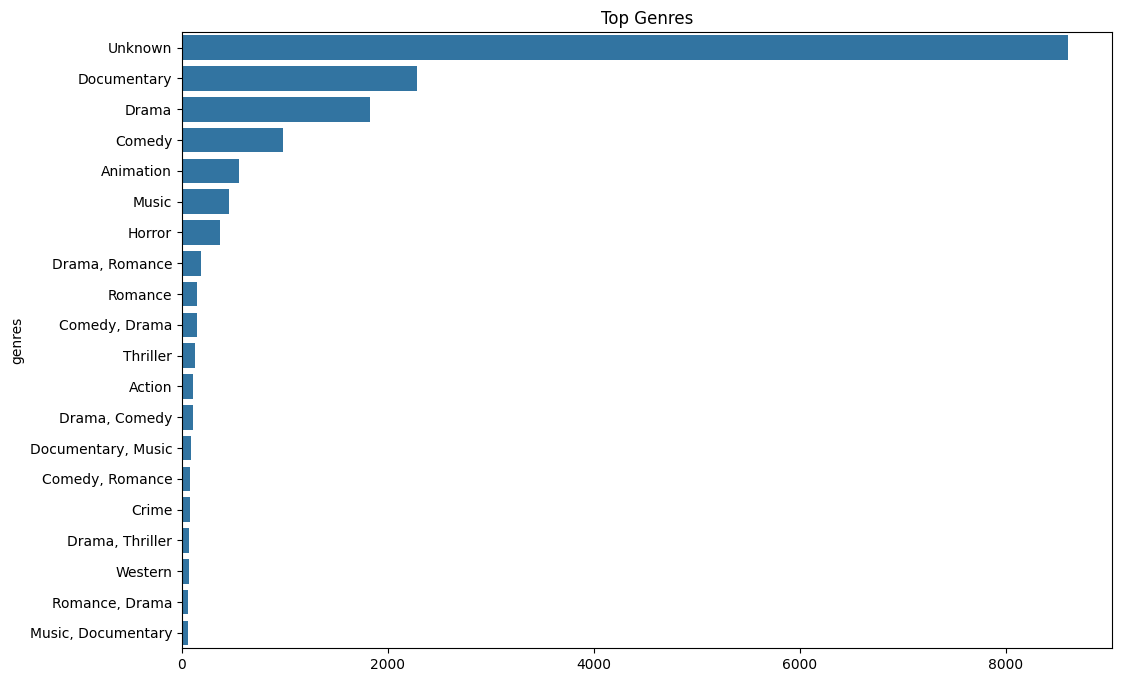

In [20]:
plt.figure(figsize=(12,8))
sns.barplot(x=genre_data.values,y=genre_data.index)
plt.title("Top Genres")
plt.show()

Popularity vs Runtime

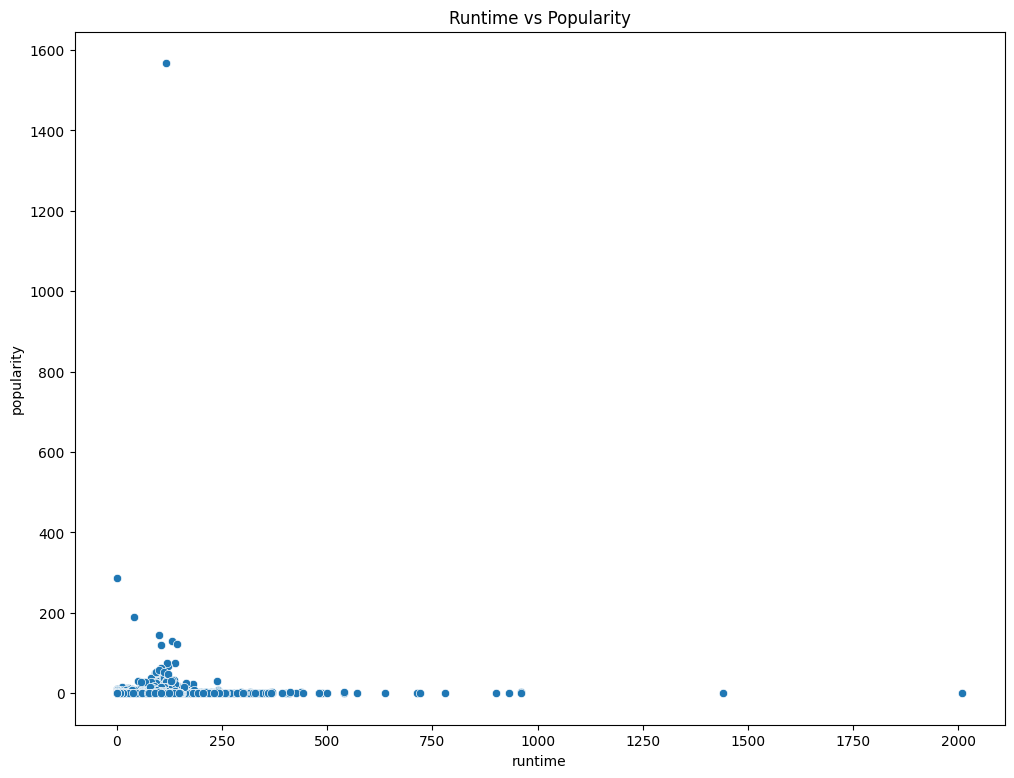

In [21]:
plt.figure(figsize=(12,9))
sns.scatterplot(x=df['runtime'],y=df['popularity'])
plt.title("Runtime vs Popularity")
plt.show()

Converting Overview Text To Number

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf=TfidfVectorizer(max_features=5000,stop_words='english')

In [24]:
vectors = tfidf.fit_transform(df['overview'])

In [25]:
tfidf

TfidfVectorizer(max_features=5000, stop_words='english')

Calculate Movies Distances

In [26]:
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cosine

In [27]:
distance_matrix =1-pairwise_distances(vectors,metric='cosine') # 1-pairwise_distances is used as it flips the scale

Recommendation Code

In [28]:
def recommend(movie_name):
    index = df[df['title'] == movie_name].index[0] #Get Index Of The Movies
    
    
    movie_similarity = [] 
    similarities = distance_matrix[index]
    for i in range(len(similarities)):
        movie_similarity.append((similarities[i], i)) #Create score and index pairs using a simple loop
    
        movie_similarity.sort(reverse=True)  #sort by score
   
    print("Recommended Movies:")  
    for i in range(1, 6):
        movie_index = movie_similarity[i][1]
        print(df.iloc[movie_index].title) 



In [29]:
recommend("Psycho")

Recommended Movies:
Tierra De Leche
Old Friends from Jiangnan
Bloom
Clifford Odets in Staten Island
Jiabiangou Elegy: Life and Death of the Rightists
